# Nassau Candy Distributor
## Product Line Profitability & Margin Performance Analysis
### Exploratory Data Analysis Notebook

**Analyst:** Anirudh Singh 
**Dataset:** Nassau_Candy_Distributor.csv  
**Period:** January 2025 – December 2025  
**Total Records:** 10,194 order rows

---

## 1. Environment Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'Chocolate': '#6B3E26',
    'Sugar':     '#E8A838',
    'Other':     '#5B8DB8',
    'accent':    '#E05C2A',
    'positive':  '#2ECC71',
    'negative':  '#E74C3C',
    'neutral':   '#95A5A6'
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading & Inspection

In [2]:
df = pd.read_csv('../data/Nassau_Candy_Distributor.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(5)

Shape: (10194, 18)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [4]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


## 3. Data Cleaning & Validation

In [ ]:
# Missing value check
print('=== Missing Values ===')
print(df.isnull().sum())

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

# Standardize product name (whitespace typo in original data)
df['Product Name'] = df['Product Name'].str.strip()

# Financial integrity check: Sales = Cost + Gross Profit
df['_check'] = (df['Sales'] - df['Cost'] - df['Gross Profit']).abs()
bad_rows = df[df['_check'] > 0.01]
print(f'\nFinancial integrity violations: {len(bad_rows)} rows')
df.drop(columns='_check', inplace=True)

# Remove zero/negative sales
before = len(df)
df = df[df['Sales'] > 0]
print(f'Removed {before - len(df)} zero/negative sales rows')

print(f'\nClean dataset: {df.shape}')
print(f'Date range: {df["Order Date"].min().date()} to {df["Order Date"].max().date()}')

=== Missing Values ===
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

Financial integrity violations: 0 rows
Removed 0 zero/negative sales rows

Clean dataset: (10194, 18)
Date range: 2024-01-02 to 2025-12-31


## 4. Feature Engineering — KPI Metrics

In [6]:
# Row-level KPIs
df['Gross Margin (%)']  = (df['Gross Profit'] / df['Sales']) * 100
df['Profit per Unit']   = df['Gross Profit'] / df['Units']
df['Revenue per Unit']  = df['Sales'] / df['Units']
df['Cost Ratio (%)']    = (df['Cost'] / df['Sales']) * 100
df['Month']             = df['Order Date'].dt.to_period('M')
df['Quarter']           = df['Order Date'].dt.to_period('Q')

# Product-level aggregation
product_df = df.groupby(['Division', 'Product Name']).agg(
    Total_Sales      = ('Sales',            'sum'),
    Total_Cost       = ('Cost',             'sum'),
    Total_Profit     = ('Gross Profit',     'sum'),
    Total_Units      = ('Units',            'sum'),
    Avg_Margin       = ('Gross Margin (%)', 'mean'),
    Order_Count      = ('Order ID',         'count')
).reset_index()
product_df['Profit_per_Unit']        = product_df['Total_Profit'] / product_df['Total_Units']
product_df['Revenue_Contribution %'] = product_df['Total_Sales']   / product_df['Total_Sales'].sum()   * 100
product_df['Profit_Contribution %']  = product_df['Total_Profit']  / product_df['Total_Profit'].sum()  * 100
product_df['Cost_Ratio %']           = product_df['Total_Cost']    / product_df['Total_Sales']          * 100

# Division-level aggregation
division_df = df.groupby('Division').agg(
    Total_Sales  = ('Sales',            'sum'),
    Total_Cost   = ('Cost',             'sum'),
    Total_Profit = ('Gross Profit',     'sum'),
    Total_Units  = ('Units',            'sum'),
    Avg_Margin   = ('Gross Margin (%)', 'mean')
).reset_index()

print('KPI features created.')
product_df[['Product Name','Division','Total_Sales','Total_Profit','Avg_Margin','Cost_Ratio %']].sort_values('Total_Profit', ascending=False)

KPI features created.


,Product Name,Division,Total_Sales,Total_Profit,Avg_Margin,Cost_Ratio %
4,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,69.444444,30.555556
3,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.333333,34.666667
1,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.923077,35.076923
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,71.346705,28.653295
0,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.666667,33.333333
6,Lickable Wallpaper,Other,7860.00,3930.00,50.000000,50.000000
7,Wonka Gum,Other,597.50,310.70,52.000000,48.000000
8,Everlasting Gobstopper,Sugar,130.00,104.00,80.000000,20.000000
5,Kazookles,Other,1205.75,92.75,7.692308,92.307692
11,Hair Toffee,Sugar,76.50,59.50,77.777778,22.222222


## 5. Overall Business KPIs

In [7]:
total_revenue = df['Sales'].sum()
total_profit  = df['Gross Profit'].sum()
avg_margin    = df['Gross Margin (%)'].mean()
total_units   = df['Units'].sum()
total_orders  = df['Order ID'].nunique()

print('=' * 45)
print('        NASSAU CANDY — 2025 KPI SUMMARY')
print('=' * 45)
print(f'  Total Revenue        :  ${total_revenue:>12,.2f}')
print(f'  Total Gross Profit   :  ${total_profit:>12,.2f}')
print(f'  Overall Gross Margin :  {avg_margin:>11.2f}%')
print(f'  Total Units Sold     :  {total_units:>12,}')
print(f'  Total Orders         :  {total_orders:>12,}')
print('=' * 45)

        NASSAU CANDY — 2025 KPI SUMMARY
  Total Revenue        :  $  141,783.63
  Total Gross Profit   :  $   93,442.80
  Overall Gross Margin :        66.51%
  Total Units Sold     :        38,654
  Total Orders         :         8,549


## 6. Chart 1 — Gross Profit by Product (Bar Chart)

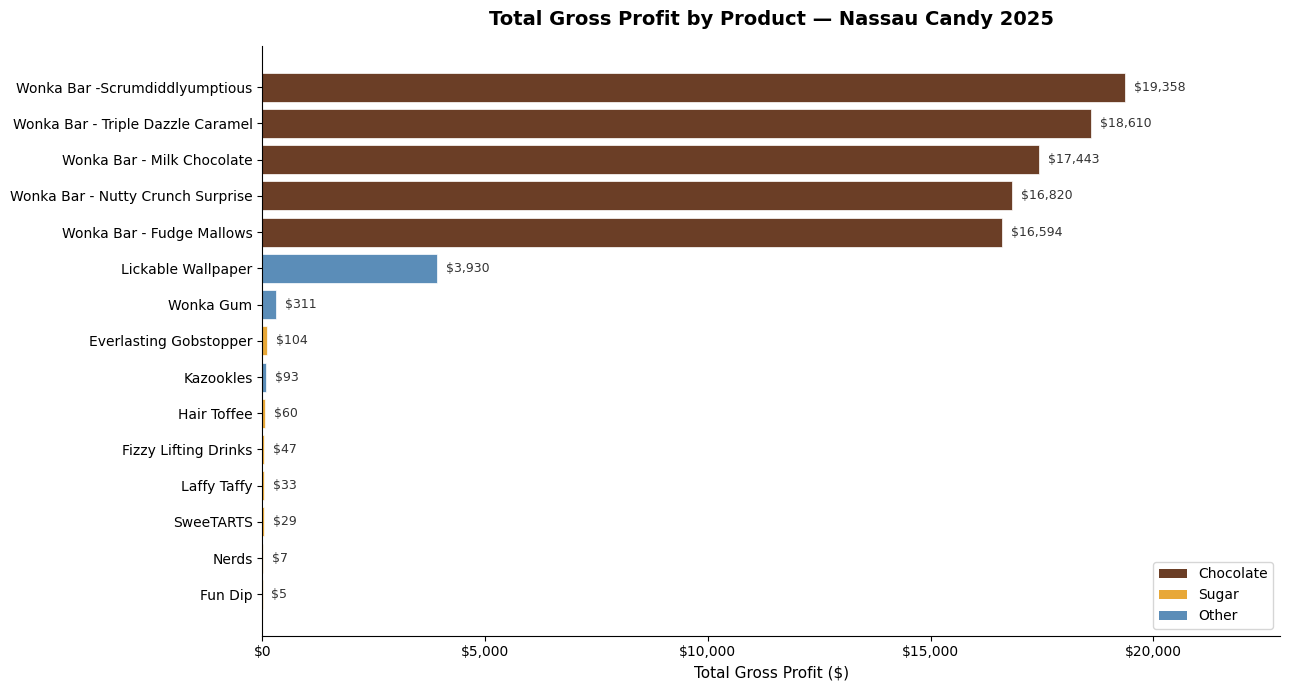

In [8]:
fig, ax = plt.subplots(figsize=(13, 7))

plot_df = product_df.sort_values('Total_Profit', ascending=True)
bar_colors = [COLORS.get(d, '#999') for d in plot_df['Division']]

bars = ax.barh(plot_df['Product Name'], plot_df['Total_Profit'],
               color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, plot_df['Total_Profit']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9, color='#333')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS[d], label=d) for d in ['Chocolate', 'Sugar', 'Other']]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel('Total Gross Profit ($)', fontsize=11)
ax.set_title('Total Gross Profit by Product — Nassau Candy 2025', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, plot_df['Total_Profit'].max() * 1.18)
plt.tight_layout()
plt.savefig('../reports/fig1_profit_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Chart 2 — Gross Margin % by Product

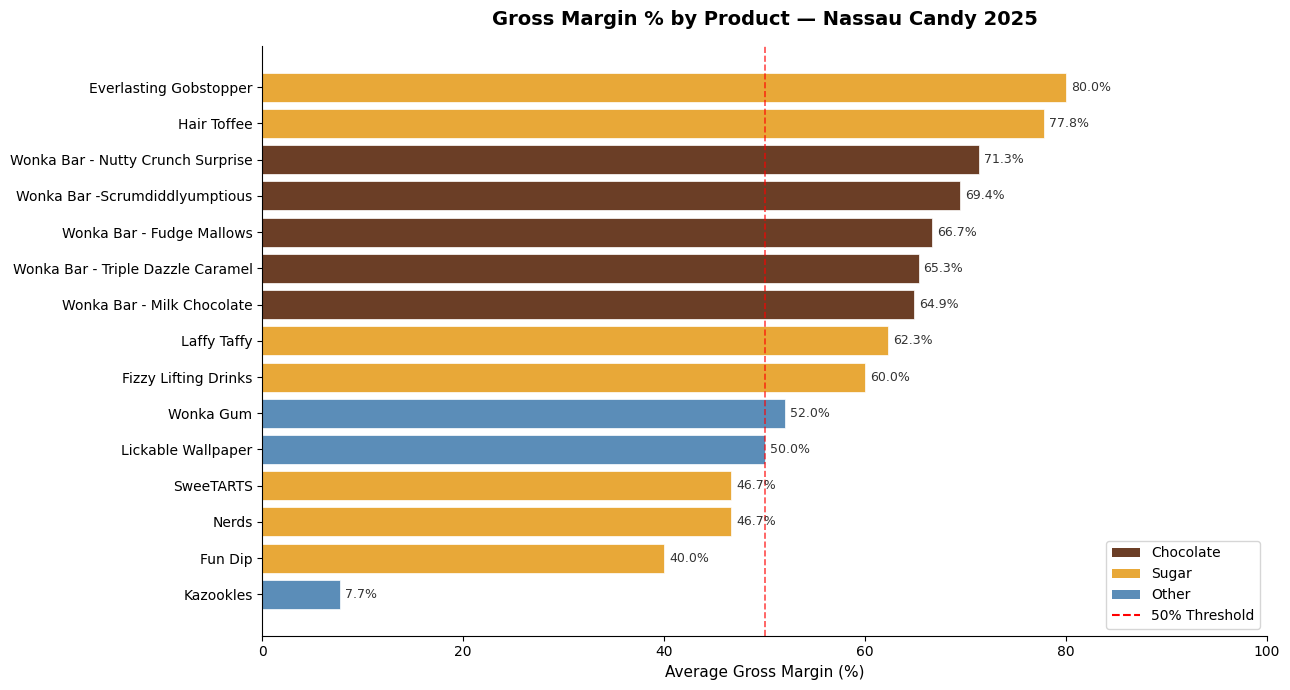

In [9]:
fig, ax = plt.subplots(figsize=(13, 7))

plot_df = product_df.sort_values('Avg_Margin', ascending=True)
bar_colors = [COLORS.get(d, '#999') for d in plot_df['Division']]

bars = ax.barh(plot_df['Product Name'], plot_df['Avg_Margin'],
               color=bar_colors, edgecolor='white', linewidth=0.5)

# 50% threshold line
ax.axvline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='50% threshold')

for bar, val in zip(bars, plot_df['Avg_Margin']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='#333')

legend_elements = [Patch(facecolor=COLORS[d], label=d) for d in ['Chocolate', 'Sugar', 'Other']]
legend_elements.append(plt.Line2D([0],[0], color='red', linestyle='--', label='50% Threshold'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel('Average Gross Margin (%)', fontsize=11)
ax.set_title('Gross Margin % by Product — Nassau Candy 2025', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('../reports/fig2_margin_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Chart 3 — Division Revenue vs. Profit Comparison

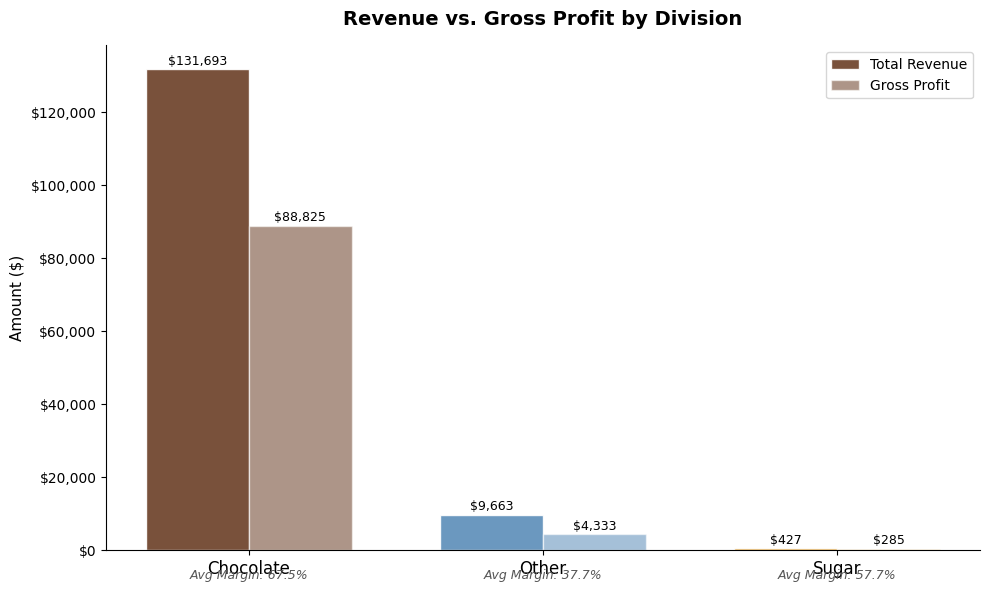

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(division_df))
width = 0.35

bars1 = ax.bar(x - width/2, division_df['Total_Sales'],   width, label='Total Revenue',
               color=['#6B3E26','#5B8DB8','#E8A838'], alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + width/2, division_df['Total_Profit'],  width, label='Gross Profit',
               color=['#6B3E26','#5B8DB8','#E8A838'], alpha=0.55, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(division_df['Division'], fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=11)
ax.set_title('Revenue vs. Gross Profit by Division', fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10)

# Avg margin annotation
for i, row in division_df.iterrows():
    ax.text(i, -8000, f'Avg Margin: {row["Avg_Margin"]:.1f}%',
            ha='center', fontsize=9, color='#555', style='italic')

plt.tight_layout()
plt.savefig('../reports/fig3_division_revenue_profit.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Chart 4 — Pareto Analysis (Profit Concentration)

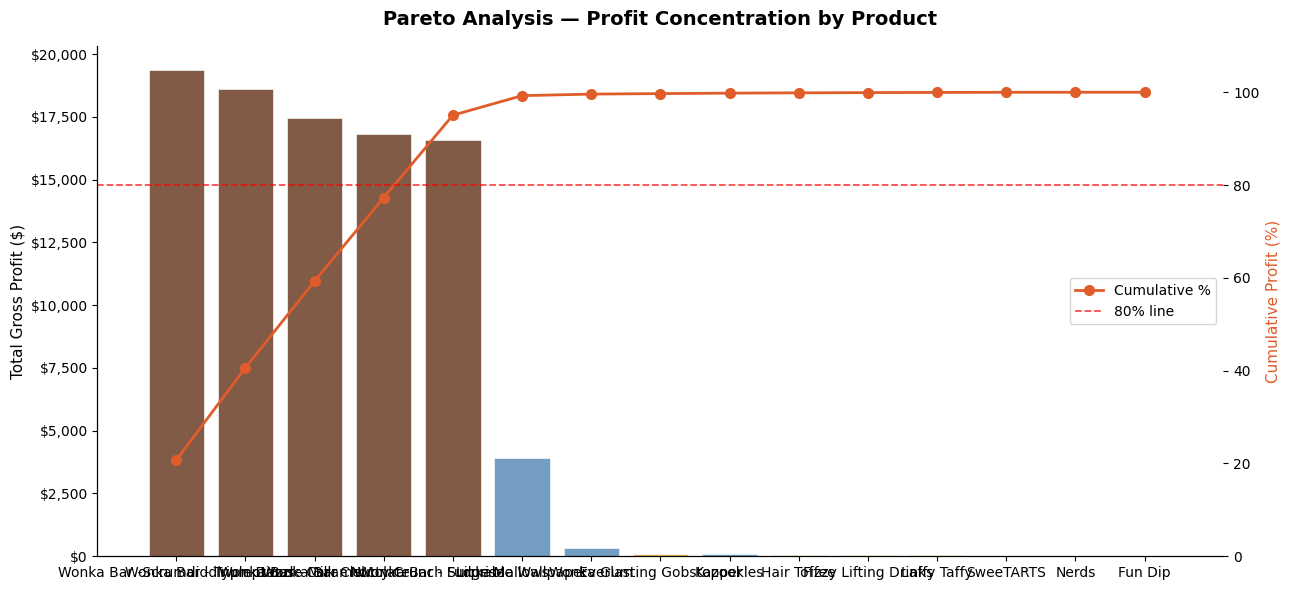


Pareto Summary:
                     Product Name  Total_Profit  Cum_Profit_%
   Wonka Bar -Scrumdiddlyumptious      19357.50     20.715882
Wonka Bar - Triple Dazzle Caramel      18610.20     40.632023
       Wonka Bar - Milk Chocolate      17443.37     59.299454
Wonka Bar - Nutty Crunch Surprise      16819.95     77.299717
        Wonka Bar - Fudge Mallows      16593.60     95.057747
               Lickable Wallpaper       3930.00     99.263528
                        Wonka Gum        310.70     99.596031
           Everlasting Gobstopper        104.00     99.707329
                        Kazookles         92.75     99.806588
                      Hair Toffee         59.50     99.870263
             Fizzy Lifting Drinks         47.25     99.920829
                      Laffy Taffy         33.48     99.956658
                        SweeTARTS         28.70     99.987372
                            Nerds          7.00     99.994863
                          Fun Dip          4.80    10

In [11]:
pareto_df = product_df.sort_values('Total_Profit', ascending=False).copy()
pareto_df['Cum_Profit_%'] = pareto_df['Total_Profit'].cumsum() / pareto_df['Total_Profit'].sum() * 100

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

bar_colors = [COLORS.get(d, '#999') for d in pareto_df['Division']]
ax1.bar(pareto_df['Product Name'], pareto_df['Total_Profit'],
        color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.85)

ax2.plot(pareto_df['Product Name'], pareto_df['Cum_Profit_%'],
         color='#E05C2A', marker='o', linewidth=2, markersize=7, label='Cumulative %')
ax2.axhline(80, color='red', linestyle='--', linewidth=1.3, alpha=0.7, label='80% line')
ax2.set_ylabel('Cumulative Profit (%)', fontsize=11, color='#E05C2A')
ax2.set_ylim(0, 110)

ax1.set_ylabel('Total Gross Profit ($)', fontsize=11)
ax1.set_title('Pareto Analysis — Profit Concentration by Product', fontsize=14, fontweight='bold', pad=15)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30, ha='right', fontsize=9)

ax2.legend(loc='center right', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/fig4_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPareto Summary:')
print(pareto_df[['Product Name','Total_Profit','Cum_Profit_%']].to_string(index=False))

## 10. Chart 5 — Sales vs. Gross Profit Scatter (Cost Diagnostics)

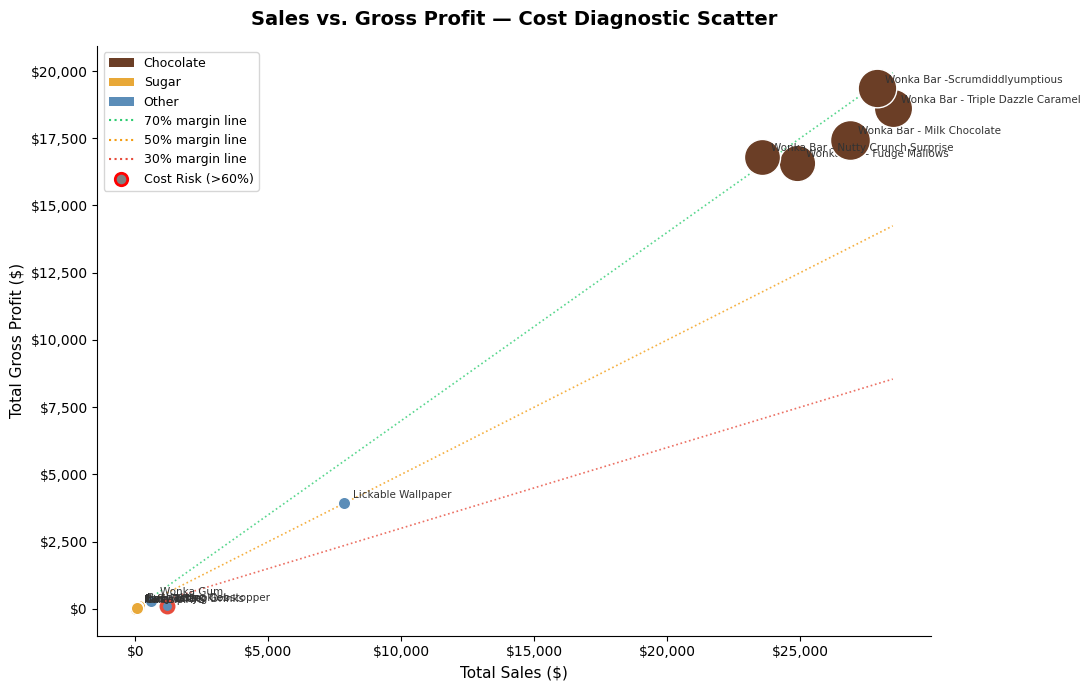

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))

for _, row in product_df.iterrows():
    color = COLORS.get(row['Division'], '#999')
    risk  = row['Cost_Ratio %'] > 60
    edge  = COLORS['negative'] if risk else 'white'
    size  = max(80, row['Total_Units'] / 10)
    ax.scatter(row['Total_Sales'], row['Total_Profit'],
               s=size, color=color, edgecolors=edge, linewidths=2.5 if risk else 1, zorder=3)
    ax.annotate(row['Product Name'], (row['Total_Sales'], row['Total_Profit']),
                textcoords='offset points', xytext=(6, 4), fontsize=7.5, color='#333')

# Perfect margin reference lines
max_s = product_df['Total_Sales'].max()
for pct, label, lc in [(0.7, '70% margin', '#2ECC71'), (0.5, '50% margin', '#F39C12'), (0.3, '30% margin', '#E74C3C')]:
    ax.plot([0, max_s], [0, max_s * pct], linestyle=':', linewidth=1.2, color=lc, alpha=0.8, label=label)

legend_elements = [Patch(facecolor=COLORS[d], label=d) for d in ['Chocolate','Sugar','Other']]
legend_elements += [
    plt.Line2D([0],[0], color='#2ECC71', linestyle=':', label='70% margin line'),
    plt.Line2D([0],[0], color='#F39C12', linestyle=':', label='50% margin line'),
    plt.Line2D([0],[0], color='#E74C3C', linestyle=':', label='30% margin line'),
    plt.scatter([],[], s=80, edgecolors='red', facecolors='gray', linewidths=2, label='Cost Risk (>60%)')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')

ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.set_ylabel('Total Gross Profit ($)', fontsize=11)
ax.set_title('Sales vs. Gross Profit — Cost Diagnostic Scatter', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/fig5_scatter_cost_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Chart 6 — Monthly Margin Trend by Division

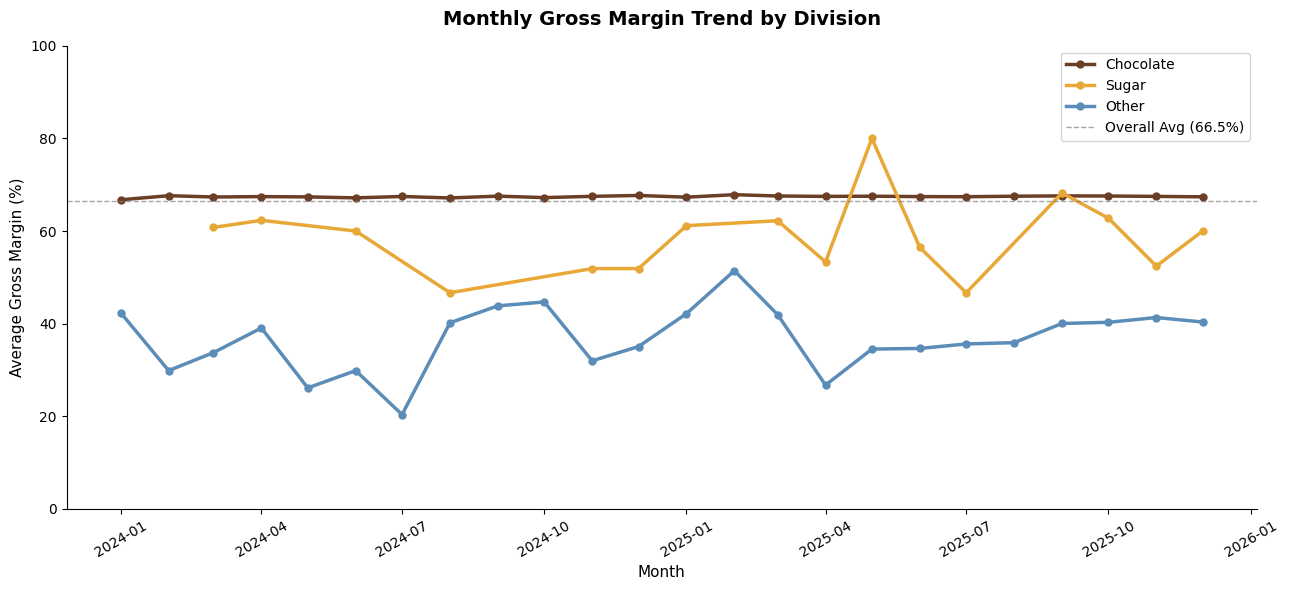

In [13]:
monthly_df = df.groupby(['Month', 'Division'])['Gross Margin (%)'].mean().reset_index()
monthly_df['Month_dt'] = monthly_df['Month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 6))

for division in ['Chocolate', 'Sugar', 'Other']:
    sub = monthly_df[monthly_df['Division'] == division]
    ax.plot(sub['Month_dt'], sub['Gross Margin (%)'],
            marker='o', linewidth=2.5, markersize=5,
            color=COLORS[division], label=division)

ax.axhline(66.51, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Overall Avg (66.5%)')
ax.set_ylabel('Average Gross Margin (%)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.set_title('Monthly Gross Margin Trend by Division', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0, 100)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/fig6_monthly_margin_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Chart 7 — Profit per Unit Heatmap by Product & Quarter

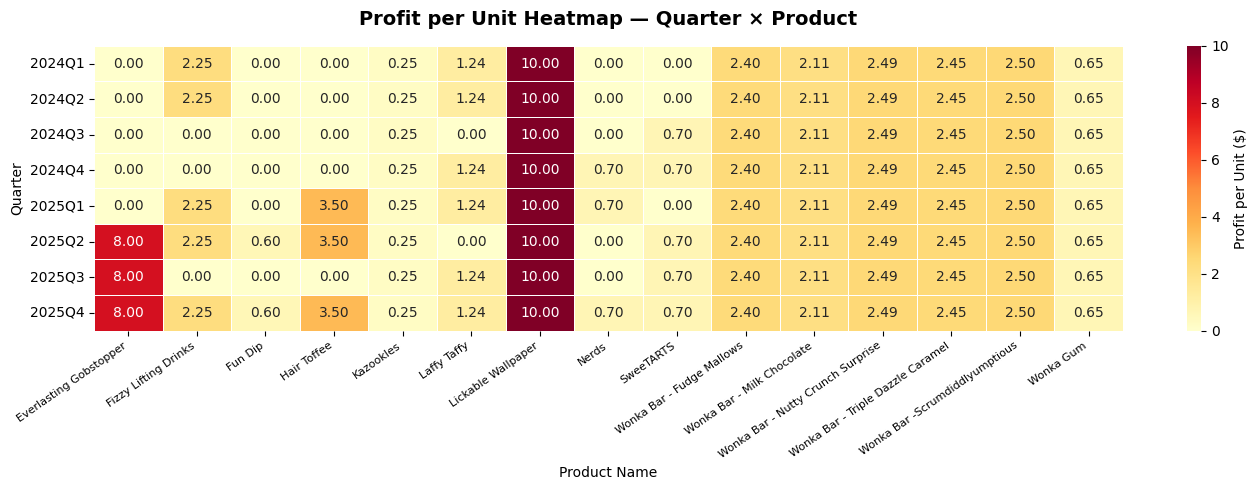

In [14]:
pivot = df.groupby(['Quarter', 'Product Name'])['Profit per Unit'].mean().unstack(fill_value=0)
pivot.index = pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Profit per Unit ($)'})
ax.set_title('Profit per Unit Heatmap — Quarter × Product', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Name', fontsize=10)
ax.set_ylabel('Quarter', fontsize=10)
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/fig7_heatmap_profit_per_unit.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Chart 8 — Regional Performance

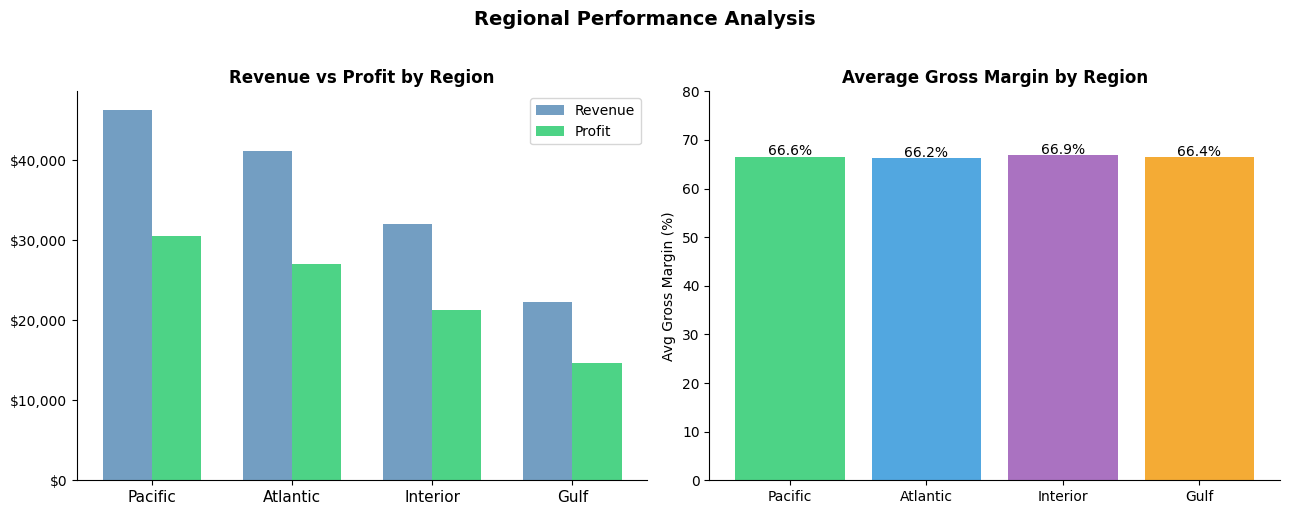

In [15]:
region_df = df.groupby('Region').agg(
    Total_Sales  = ('Sales',            'sum'),
    Total_Profit = ('Gross Profit',     'sum'),
    Avg_Margin   = ('Gross Margin (%)', 'mean')
).reset_index().sort_values('Total_Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: revenue & profit bars
x = np.arange(len(region_df))
w = 0.35
axes[0].bar(x - w/2, region_df['Total_Sales'],   w, label='Revenue', color='#5B8DB8', alpha=0.85)
axes[0].bar(x + w/2, region_df['Total_Profit'],  w, label='Profit',  color='#2ECC71', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(region_df['Region'], fontsize=11)
axes[0].set_title('Revenue vs Profit by Region', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Right: avg margin
bars = axes[1].bar(region_df['Region'], region_df['Avg_Margin'],
                   color=['#2ECC71','#3498DB','#9B59B6','#F39C12'], alpha=0.85)
for bar, val in zip(bars, region_df['Avg_Margin']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Average Gross Margin by Region', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Gross Margin (%)', fontsize=10)
axes[1].set_ylim(0, 80)

plt.suptitle('Regional Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig8_regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Key Findings Summary

In [16]:
print('=' * 60)
print('         NASSAU CANDY — EDA KEY FINDINGS')
print('=' * 60)

top3 = product_df.nlargest(3, 'Total_Profit')[['Product Name','Total_Profit','Avg_Margin']]
print('\nTOP 3 PRODUCTS BY GROSS PROFIT:')
for _, r in top3.iterrows():
    print(f'  {r["Product Name"]:<40} ${r["Total_Profit"]:>10,.2f}  (Margin: {r["Avg_Margin"]:.1f}%)')

risk = product_df[product_df['Cost_Ratio %'] > 60].sort_values('Cost_Ratio %', ascending=False)
print('\nMARGIN RISK PRODUCTS (Cost Ratio > 60%):')
for _, r in risk.iterrows():
    print(f'  {r["Product Name"]:<40} Cost Ratio: {r["Cost_Ratio %"]:.1f}%  Margin: {r["Avg_Margin"]:.1f}%')

print('\nDIVISION PERFORMANCE:')
for _, r in division_df.sort_values('Avg_Margin', ascending=False).iterrows():
    share = r['Total_Sales'] / division_df['Total_Sales'].sum() * 100
    print(f'  {r["Division"]:<12}  Revenue: ${r["Total_Sales"]:>10,.0f} ({share:.1f}%)  Avg Margin: {r["Avg_Margin"]:.1f}%')

print('\nPARETO:')
top5_pct = product_df.nlargest(5,'Total_Profit')['Profit_Contribution %'].sum()
print(f'  Top 5 products (33% of SKUs) = {top5_pct:.1f}% of total profit')
print('\n' + '=' * 60)

         NASSAU CANDY — EDA KEY FINDINGS

TOP 3 PRODUCTS BY GROSS PROFIT:
  Wonka Bar -Scrumdiddlyumptious           $ 19,357.50  (Margin: 69.4%)
  Wonka Bar - Triple Dazzle Caramel        $ 18,610.20  (Margin: 65.3%)
  Wonka Bar - Milk Chocolate               $ 17,443.37  (Margin: 64.9%)

MARGIN RISK PRODUCTS (Cost Ratio > 60%):
  Kazookles                                Cost Ratio: 92.3%  Margin: 7.7%

DIVISION PERFORMANCE:
  Chocolate     Revenue: $   131,693 (92.9%)  Avg Margin: 67.5%
  Sugar         Revenue: $       427 (0.3%)  Avg Margin: 57.7%
  Other         Revenue: $     9,663 (6.8%)  Avg Margin: 37.7%

PARETO:
  Top 5 products (33% of SKUs) = 95.1% of total profit



---
**End of EDA Notebook**  
*Nassau Candy Distributor — Product Line Profitability Analysis 2025*